In [2]:
!pip install numpy pandas scipy statsmodels matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm 
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다.
np.random.seed(42)

# 한글 폰트 설정
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료!")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("scipy :", stats.__name__)

준비 완료!
numpy : 2.4.6
pandas: 3.0.3
scipy : scipy.stats


In [3]:
# ─────────────────────────────────────────────
# [C2] 실습 데이터 로드 — 전부 '라이브러리가 제공하는' 데이터셋
#   (1) seaborn                    : tips / titanic / penguins
#   (2) statsmodels 내장            : strikes
#   (3) statsmodels 경유 Rdatasets  : Medicaid1986 / ResumeNames
# ─────────────────────────────────────────────

# ── (1) seaborn 데이터셋 3종 ──
tips     = sns.load_dataset("tips")        # 식당 영수증 (결제액·팁·성별·시간대)
titanic  = sns.load_dataset("titanic")     # 타이타닉 승객 (운임·나이·생존)
penguins = sns.load_dataset("penguins")    # 펭귄 신체 측정 (종·체중·부리)

# ── (2) statsmodels에 함께 설치된 데이터 ──
strikes = sm.datasets.strikes.load_pandas().data      # 파업 62건: duration = 지속일수

# ── (3) statsmodels가 중계하는 Rdatasets(공개 저장소) ──
med    = sm.datasets.get_rdataset("Medicaid1986", "AER").data   # 996명: visits = 2년간 진료 방문 횟수
resume = sm.datasets.get_rdataset("ResumeNames", "AER").data    # 이력서 4,870건: call = 면접 연락 여부

# 오늘 자주 쓸 변수에 짧은 이름을 붙여 둡니다.
visits = med["visits"]                          # 발생 '횟수'  (0,1,2,… 이산형) → 포아송 후보
wait   = strikes["duration"]                    # 지속 '시간'  (양수 연속형)    → 지수 후보
call   = (resume["call"] == "yes").astype(int)   # 0/1 '여부'   → 비율 → 베타 후보

print("로드 완료 ✓  (모두 라이브러리 제공 데이터셋)")
print(f"  tips     {str(tips.shape):9s} · 식당 영수증")
print(f"  titanic  {str(titanic.shape):9s} · 승객 (운임·나이)")
print(f"  penguins {str(penguins.shape):9s} · 펭귄 (종·체중)")
print(f"  strikes  {str(strikes.shape):9s} · 파업 지속일수      → wait   (평균 {wait.mean():.1f}일)")
print(f"  Medicaid {str(med.shape):9s} · 2년간 진료 방문 횟수 → visits (평균 {visits.mean():.2f}회)")
print(f"  Resume   {str(resume.shape):9s} · 면접 연락 여부      → call   (연락률 {call.mean():.2%})")
titanic.head()

로드 완료 ✓  (모두 라이브러리 제공 데이터셋)
  tips     (244, 7)  · 식당 영수증
  titanic  (891, 15) · 승객 (운임·나이)
  penguins (344, 7)  · 펭귄 (종·체중)
  strikes  (62, 2)   · 파업 지속일수      → wait   (평균 42.7일)
  Medicaid (996, 14) · 2년간 진료 방문 횟수 → visits (평균 1.93회)
  Resume   (4870, 27) · 면접 연락 여부      → call   (연락률 8.05%)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# [C3] 예제 1.1: 평균·중앙값·표준편차·IQR — pandas로 한 번에
fare = titanic["fare"].dropna()
print(f"타이타닉 운임(fare) 표본 크기 n = {len(fare)}")
print(f"표본평균 x̄ = {fare.mean():,.2f}")
print(f"중앙값   = {fare.median():,.2f}")
print(f"표본표준편차 s = {fare.std():,.2f}")
print(f"Q1 = {fare.quantile(0.25):,.2f}")
print(f"Q3 = {fare.quantile(0.75):,.2f}")
print(f"IQR = Q3 - Q1 = {fare.quantile(0.75) - fare.quantile(0.25):,.2f}")
print(f"최솟값 = {fare.min():,.2f}, 최댓값 = {fare.max():,.2f}")

타이타닉 운임(fare) 표본 크기 n = 891
표본평균 x̄ = 32.20
중앙값   = 14.45
표본표준편차 s = 49.69
Q1 = 7.91
Q3 = 31.00
IQR = Q3 - Q1 = 23.09
최솟값 = 0.00, 최댓값 = 512.33


In [5]:
# [C4] 예제 1.2: describe() — 한 번에 보기 (운임 vs 나이)
titanic[["fare", "age"]].describe().round(2)

,fare,age
count,891.00,714.00
mean,32.20,29.70
std,49.69,14.53
min,0.00,0.42
25%,7.91,20.12
50%,14.45,28.00
75%,31.00,38.00
max,512.33,80.00


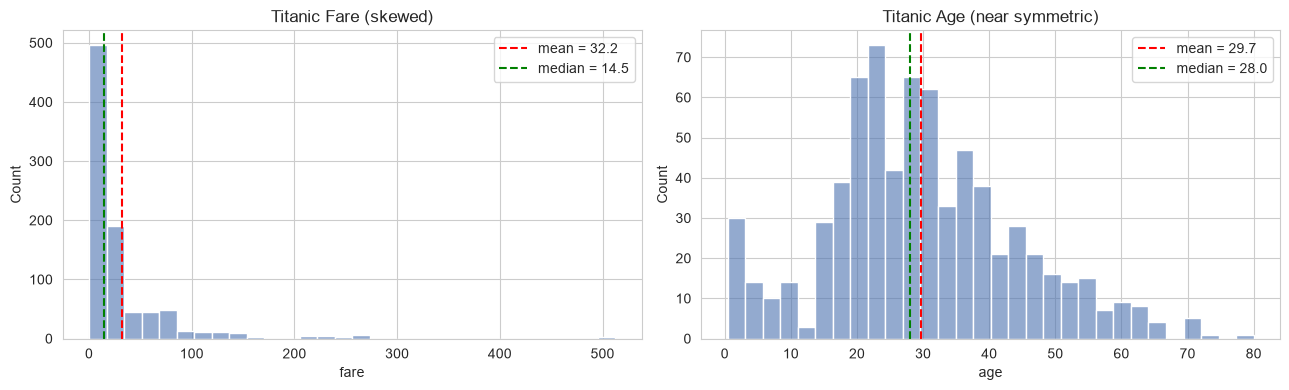

In [6]:
# [C5] 예제 1.3: 평균과 중앙값을 그림에 함께 — 분포가 한쪽으로 치우치면 두 값이 갈라진다
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(axes,
                          ["fare", "age"],
                          ["Titanic Fare (skewed)", "Titanic Age (near symmetric)"]):
    s = titanic[col].dropna()
    sns.histplot(s, bins=30, ax=ax, color="#4C72B0", alpha=0.6)
    ax.axvline(s.mean(),   color="red",   linestyle="--", label=f"mean = {s.mean():,.1f}")
    ax.axvline(s.median(), color="green", linestyle="--", label=f"median = {s.median():,.1f}")
    ax.set_title(title)
    ax.legend()

plt.tight_layout(); plt.show()

[문제]
1) visits(2년간 진료 방문 횟수)의 평균·중앙값·표준편차·IQR을 출력해보세요.
2) titanic["fare"]와 tips["total_bill"] 둘 다 "금액"인데, 두 변수의 변동계수(CV)를 비교해보세요.
   어떤 변수가 상대적으로 더 흔들립니까?
3) 같은 평균인데 표준편차가 큰 두 데이터가 있다면, 비즈니스 관점에서 어느 쪽이 예측하기
   어렵다고 할 수 있을지 판단과 근거를 주석으로 정리해보세요.
   - 표준편차가 큰 쪽이 훨씬 예측하기 어렵다, 평균은 장기적으로 반복했을때의 기대값일 뿐, 예측에는 큰 도움이 되지 않는다
   예측을 하기 위해서는 값의 범위가 좁은게 유리하므로 비즈니스적 관점에서 같은 평균이어도 표준편차가 큰 쪽이 훨씬 예측하기 어렵다.

In [7]:
visits = med["visits"].dropna()
print(f"visits n = {len(visits)}")
print(f"표본평균 x̄ = {visits.mean():,.2f}")
print(f"중앙값   = {visits.median():,.2f}")
print(f"표본표준편차 s = {visits.std():,.2f}")
print(f"Q1 = {visits.quantile(0.25):,.2f}")
print(f"Q3 = {visits.quantile(0.75):,.2f}")
print(f"IQR = Q3 - Q1 = {visits.quantile(0.75) - visits.quantile(0.25):,.2f}")
print(f"최솟값 = {visits.min():,.2f}, 최댓값 = {visits.max():,.2f}")  # 2년간 진료 방문 횟수 (0,1,2,… 이산형) → 포아송 후보

# ─────────────────────────────────────────────
# 2) 변동계수(CV, Coefficient of Variation) 비교
#    CV = 표준편차 / 평균  → 단위와 무관하게 "상대적 변동성"을 비교할 수 있음
#    (원, 달러처럼 단위가 다르거나, 평균 자체가 다른 두 변수를 비교할 때 필수)
# ─────────────────────────────────────────────

fare_mean, fare_std = titanic["fare"].mean(), titanic["fare"].std()
bill_mean, bill_std = tips["total_bill"].mean(), tips["total_bill"].std()

cv_fare = fare_std / fare_mean
cv_bill = bill_std / bill_mean

print(f"[타이타닉 운임(fare)]     평균={fare_mean:.2f}, 표준편차={fare_std:.2f}, CV={cv_fare:.3f}")
print(f"[식당 결제액(total_bill)] 평균={bill_mean:.2f}, 표준편차={bill_std:.2f}, CV={cv_bill:.3f}")

if cv_fare > cv_bill:
    print(f"\n→ fare가 상대적으로 더 흔들림 (CV {cv_fare:.2f} > {cv_bill:.2f})")
else:
    print(f"\n→ total_bill이 상대적으로 더 흔들림 (CV {cv_bill:.2f} > {cv_fare:.2f})")

visits n = 996
표본평균 x̄ = 1.93
중앙값   = 1.00
표본표준편차 s = 3.35
Q1 = 0.00
Q3 = 3.00
IQR = Q3 - Q1 = 3.00
최솟값 = 0.00, 최댓값 = 50.00
[타이타닉 운임(fare)]     평균=32.20, 표준편차=49.69, CV=1.543
[식당 결제액(total_bill)] 평균=19.79, 표준편차=8.90, CV=0.450

→ fare가 상대적으로 더 흔들림 (CV 1.54 > 0.45)


In [8]:
# [C7] 예제 2.1: 여러 실변수의 왜도·첨도를 한 표로
def summarize_shape(named_series):
    rows = []
    for name, s in named_series:
        s = s.dropna()
        rows.append({
            "변수": name,
            "평균": s.mean(),
            "중앙값": s.median(),
            "표준편차": s.std(),
            "왜도(skew)": stats.skew(s),
            "첨도(kurt)": stats.kurtosis(s),
        })
    return pd.DataFrame(rows).round(2)

shape_table = summarize_shape([
    ("titanic.fare",            titanic["fare"]),
    ("tips.total_bill",         tips["total_bill"]),
    ("titanic.age",             titanic["age"]),
    ("penguins.body_mass_g",    penguins["body_mass_g"]),
    ("penguins.flipper_len_mm", penguins["flipper_length_mm"]),
])
shape_table

,변수,평균,중앙값,표준편차,왜도(skew),첨도(kurt)
0,titanic.fare,32.20,14.45,49.69,4.78,33.20
1,tips.total_bill,19.79,17.80,8.90,1.13,1.17
2,titanic.age,29.70,28.00,14.53,0.39,0.17
3,penguins.body_mass_g,4201.75,4050.00,801.95,0.47,-0.73
4,penguins.flipper_len_mm,200.92,197.00,14.06,0.34,-0.99


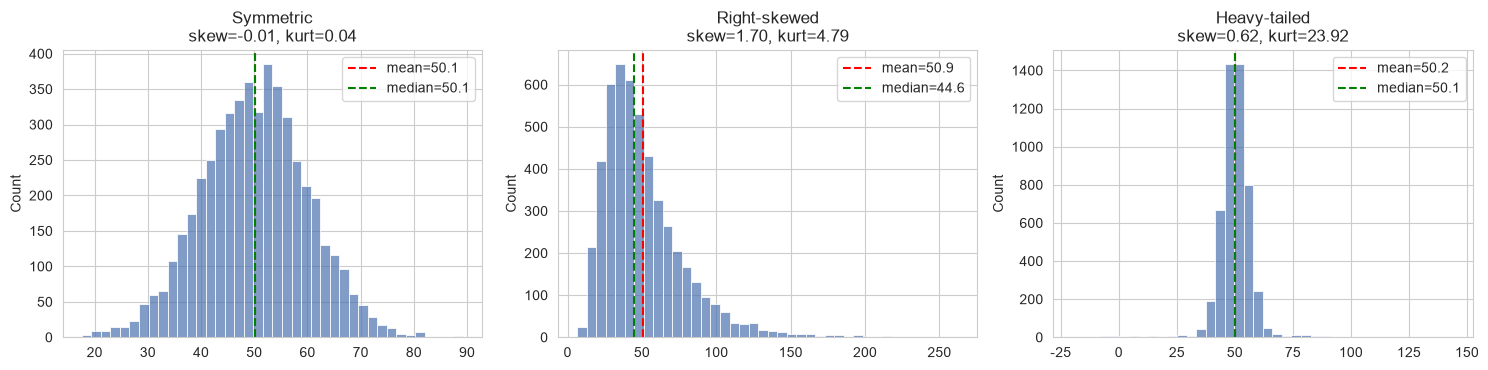

세 분포의 평균은 거의 같지만 모양은 전혀 다릅니다.


In [9]:
# [C8] 예제 2.2: 같은 평균인데 다른 모양 — 인공 데이터 세 개
np.random.seed(42)
N = 5000
sym  = np.random.normal(loc=50, scale=10, size=N)              # 좌우 대칭
right = np.random.lognormal(mean=np.log(45), sigma=0.5, size=N) # 우편향
heavy = np.concatenate([
    np.random.normal(loc=50, scale=5,  size=int(N*0.95)),
    np.random.normal(loc=50, scale=30, size=int(N*0.05)),       # 5% 극단값
])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, data, name in zip(axes,
                          [sym, right, heavy],
                          ["Symmetric", "Right-skewed", "Heavy-tailed"]):
    sns.histplot(data, bins=40, ax=ax, color="#4C72B0", alpha=0.7)
    ax.axvline(np.mean(data), color="red",   linestyle="--",
               label=f"mean={np.mean(data):.1f}")
    ax.axvline(np.median(data), color="green", linestyle="--",
               label=f"median={np.median(data):.1f}")
    ax.set_title(f"{name}\nskew={stats.skew(data):.2f}, kurt={stats.kurtosis(data):.2f}")
    ax.legend()
plt.tight_layout(); plt.show()

print("세 분포의 평균은 거의 같지만 모양은 전혀 다릅니다.")

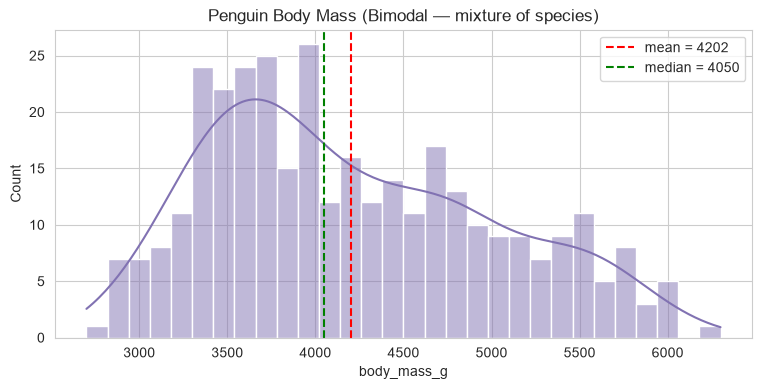

왜도: 0.47
첨도: -0.73  (음수 → 납작/다봉 신호)
→ 왜도가 0에 가깝다고 해서 정규분포라는 뜻은 아닙니다!


In [10]:
# [C9] 예제 2.3: 다봉 분포 — '평균'이 어디에도 없는 값일 때
bm = penguins["body_mass_g"].dropna()
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(bm, bins=30, kde=True, ax=ax, color="#8172B2")
ax.axvline(bm.mean(),   color="red",   linestyle="--", label=f"mean = {bm.mean():.0f}")
ax.axvline(bm.median(), color="green", linestyle="--", label=f"median = {bm.median():.0f}")
ax.set_title("Penguin Body Mass (Bimodal — mixture of species)")
ax.set_xlabel("body_mass_g")
ax.legend(); plt.show()

print(f"왜도: {stats.skew(bm):.2f}")
print(f"첨도: {stats.kurtosis(bm):.2f}  (음수 → 납작/다봉 신호)")
print("→ 왜도가 0에 가깝다고 해서 정규분포라는 뜻은 아닙니다!")

[문제]
1) titanic["fare"]의 왜도·첨도를 출력하고, 양의 왜도가 큰지 확인해보세요.
2) np.log1p(titanic["fare"])(로그 변환)의 왜도가 얼마나 줄어드는지 비교해보세요.
3) 어떤 변수의 왜도가 거의 0인데 첨도가 매우 크다면 분포 그림이 어떻게 생겼을지,
   추정과 근거를 주석으로 정리해보세요.
   - 거의 대칭인 상태로 양쪽 꼬리가 길고 매우 뾰족한 형태의 분포가 된다.
   왜도가 0에 가까우면 대칭의 형태를 띄게 되고 첨도가 매우 크면 굉장히 높은 분포가 된다 
   하지만 왜도가 0에 가깝다고 정규분포의 형태는 아니다.

In [11]:
# ─────────────────────────────────────────────
# 1) titanic["fare"]의 왜도(skewness) · 첨도(kurtosis)
# ─────────────────────────────────────────────

fare_skew = titanic["fare"].skew()
fare_kurt = titanic["fare"].kurt()   # pandas는 기본적으로 "초과 첨도(excess kurtosis)"를 반환 (정규분포=0 기준)

print(f"fare 왜도(skewness) = {fare_skew:.3f}")
print(f"fare 첨도(kurtosis) = {fare_kurt:.3f}")

if fare_skew > 1:
    print("→ 왜도가 1보다 커서 '심한 양의 왜도(right-skewed)'로 판단할 수 있음")
elif fare_skew > 0:
    print("→ 양의 왜도(오른쪽 꼬리가 긴 분포)이지만 정도는 상대적으로 약함")
else:
    print("→ 음의 왜도 혹은 대칭에 가까움")

fare 왜도(skewness) = 4.787
fare 첨도(kurtosis) = 33.398
→ 왜도가 1보다 커서 '심한 양의 왜도(right-skewed)'로 판단할 수 있음


In [12]:
# ─────────────────────────────────────────────
# 2) 로그 변환 후 왜도 비교
#    log1p(x) = log(1+x)  → 0값이 있어도 안전하게 로그를 취할 수 있음
# ─────────────────────────────────────────────

fare_log = np.log1p(titanic["fare"])
fare_log_skew = fare_log.skew()

print(f"원본 fare        왜도 = {fare_skew:.3f}")
print(f"log1p(fare)      왜도 = {fare_log_skew:.3f}")
print(f"왜도 감소폭       = {fare_skew - fare_log_skew:.3f}")
print(f"감소율           = {(1 - fare_log_skew/fare_skew) * 100:.1f}%")

원본 fare        왜도 = 4.787
log1p(fare)      왜도 = 0.395
왜도 감소폭       = 4.392
감소율           = 91.8%


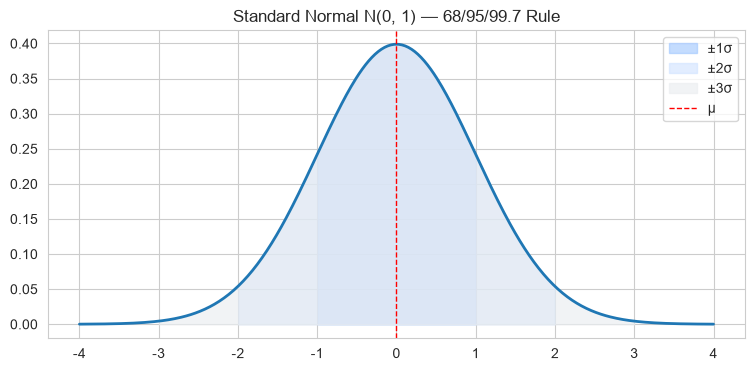

±1σ 안 확률: 0.683
±2σ 안 확률: 0.954
±3σ 안 확률: 0.997


In [13]:
# [C11] 예제 3.1: 정규분포 PDF — 68-95-99.7 규칙
mu, sigma = 0, 1
x = np.linspace(-4, 4, 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, pdf, lw=2)
for k, color in zip([1, 2, 3], ["#9ec5fe", "#cfe2ff", "#e9ecef"]):
    ax.fill_between(x, pdf, where=(x >= -k) & (x <= k), color=color, alpha=0.6,
                    label=f"±{k}σ")
ax.axvline(mu, color="red", linestyle="--", lw=1, label="μ")
ax.set_title("Standard Normal N(0, 1) — 68/95/99.7 Rule")
ax.legend(); plt.show()

print("±1σ 안 확률:", round(stats.norm.cdf(1) - stats.norm.cdf(-1), 3))
print("±2σ 안 확률:", round(stats.norm.cdf(2) - stats.norm.cdf(-2), 3))
print("±3σ 안 확률:", round(stats.norm.cdf(3) - stats.norm.cdf(-3), 3))

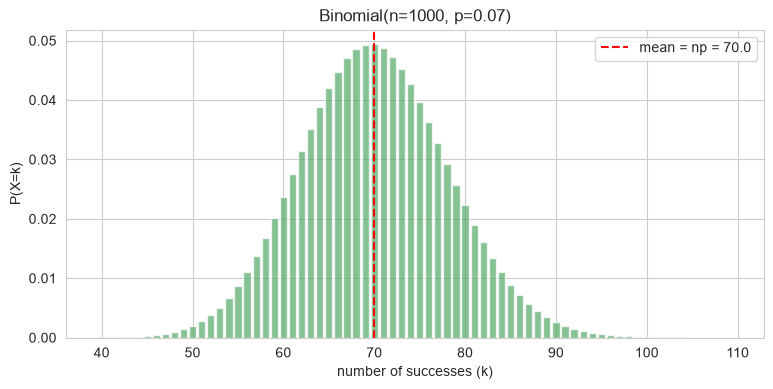

이론 평균(np): 70.0, 표본평균: 69.6
이론 표준편차: 8.07, 표본표준편차: 8.07


In [14]:
# [C12] 예제 3.2: 이항분포 — n=1000, p=0.07 (쿠폰 사용 횟수)
n_trials, p = 1000, 0.07
x = np.arange(40, 110)
pmf = stats.binom.pmf(x, n_trials, p)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x, pmf, color="#55A868", alpha=0.7)
ax.axvline(n_trials * p, color="red", linestyle="--", label=f"mean = np = {n_trials*p}")
ax.set_title(f"Binomial(n={n_trials}, p={p})")
ax.set_xlabel("number of successes (k)"); ax.set_ylabel("P(X=k)")
ax.legend(); plt.show()

# 같은 분포에서 표본을 뽑아 이론과 비교 (시뮬레이션, seed 고정)
sample = stats.binom.rvs(n_trials, p, size=365, random_state=42)
print(f"이론 평균(np): {n_trials*p:.1f}, 표본평균: {sample.mean():.1f}")
print(f"이론 표준편차: {np.sqrt(n_trials*p*(1-p)):.2f}, 표본표준편차: {sample.std():.2f}")

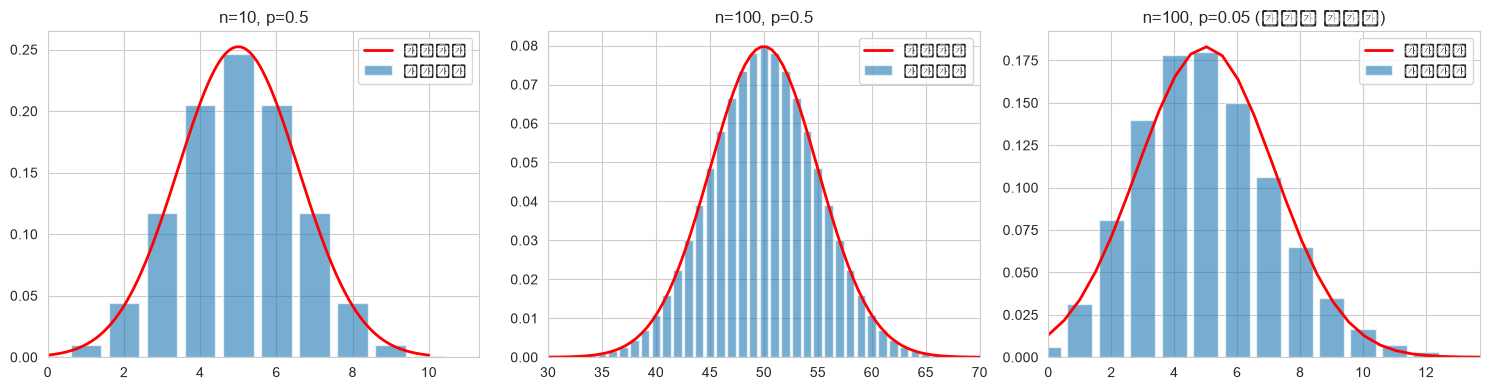

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    (10, 0.5, "n=10, p=0.5"),
    (100, 0.5, "n=100, p=0.5"),
    (100, 0.05, "n=100, p=0.05 (여전히 치우침)")
]

for ax, (n, p, title) in zip(axes, configs):
    k = np.arange(0, n+1)
    pmf = binom.pmf(k, n, p)
    ax.bar(k, pmf, alpha=0.6, label="이항분포")

    mu, sigma = n*p, np.sqrt(n*p*(1-p))
    x = np.linspace(0, n, 200)
    ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label="정규근사")
    ax.set_title(title)
    ax.set_xlim(max(0, mu-4*sigma), mu+4*sigma)
    ax.legend()

plt.tight_layout()
plt.savefig("binomial_normal.png", dpi=100)
plt.show()

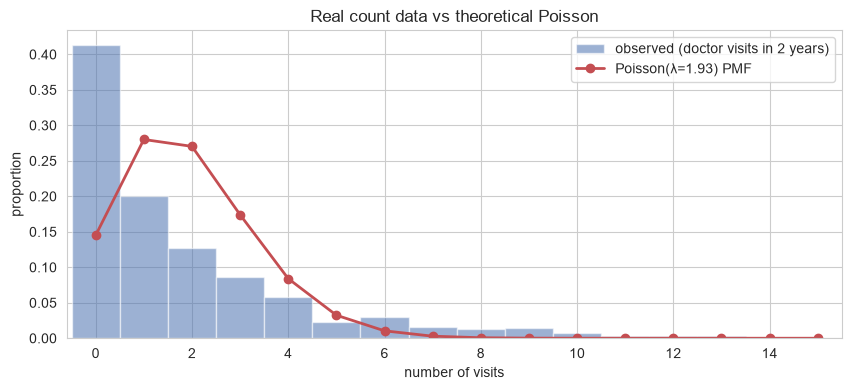

■ 포아송 가정 점검 ①  평균 ≈ 분산인가?
   표본평균 1.93   표본분산 11.25
   분산/평균 = 5.83   (1이면 포아송, 1보다 크면 '과대산포')

■ 포아송 가정 점검 ②  0회의 비율이 이론과 맞는가?
   관측 0회 비율      41.2%
   포아송이 예측하는 값 14.5%


In [16]:
# [C13] 예제 3.3: 포아송 — 실데이터('2년간 진료 방문 횟수')와 이론 PMF 비교
lam = visits.mean()                       # λ 추정치 = 표본평균
x = np.arange(0, 16)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(visits, bins=np.arange(0, 17) - 0.5, density=True, alpha=0.55,
        color="#4C72B0", label="observed (doctor visits in 2 years)")
ax.plot(x, stats.poisson.pmf(x, lam), "o-", color="#C44E52", lw=2,
        label=f"Poisson(λ={lam:.2f}) PMF")
ax.set_xlim(-0.6, 15.5)
ax.set_xlabel("number of visits"); ax.set_ylabel("proportion")
ax.set_title("Real count data vs theoretical Poisson")
ax.legend(); plt.show()

print("■ 포아송 가정 점검 ①  평균 ≈ 분산인가?")
print(f"   표본평균 {visits.mean():.2f}   표본분산 {visits.var():.2f}")
print(f"   분산/평균 = {visits.var() / visits.mean():.2f}   (1이면 포아송, 1보다 크면 '과대산포')")
print("\n■ 포아송 가정 점검 ②  0회의 비율이 이론과 맞는가?")
print(f"   관측 0회 비율      {np.mean(visits == 0):.1%}")
print(f"   포아송이 예측하는 값 {stats.poisson.pmf(0, lam):.1%}")

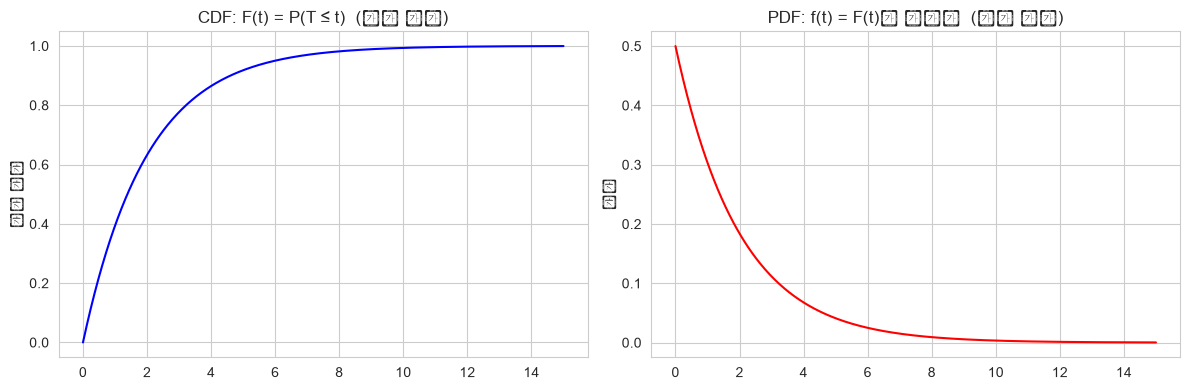

t=2 에서 CDF의 수치미분: 0.1826609533543877
t=2 에서 이론적 PDF:     0.18393972058572117


In [17]:
#CDF PDF 차이
import numpy as np
import matplotlib.pyplot as plt

lam = 0.5
t = np.linspace(0, 15, 500)

cdf = 1 - np.exp(-lam * t)      # F(t)
pdf = lam * np.exp(-lam * t)    # f(t)  = F(t)를 미분한 것

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t, cdf, color='blue')
axes[0].set_title("CDF: F(t) = P(T ≤ t)  (누적 확률)")
axes[0].set_ylabel("누적 확률")

axes[1].plot(t, pdf, color='red')
axes[1].set_title("PDF: f(t) = F(t)의 기울기  (확률 밀도)")
axes[1].set_ylabel("밀도")

plt.tight_layout()
plt.savefig("cdf_vs_pdf.png", dpi=100)
plt.show()

# 수치적으로도 확인: CDF의 기울기(수치미분) ≈ PDF
numerical_derivative = np.gradient(cdf, t)
print("t=2 에서 CDF의 수치미분:", numerical_derivative[np.argmin(np.abs(t-2))])
print("t=2 에서 이론적 PDF:    ", lam * np.exp(-lam*2))

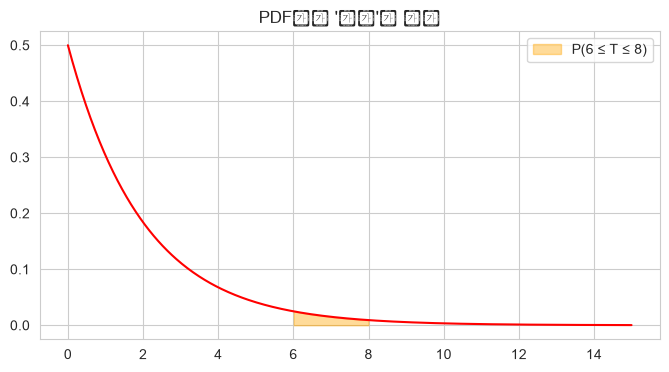

P(6 ≤ T ≤ 8) = 0.0315


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

lam = 0.5
t = np.linspace(0, 15, 500)
pdf = expon.pdf(t, scale=1/lam)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(t, pdf, color='red')

# 6~8일 사이 구간에 색칠 (이 넓이가 곧 확률)
mask = (t >= 6) & (t <= 8)
ax.fill_between(t[mask], pdf[mask], alpha=0.4, color='orange', label="P(6 ≤ T ≤ 8)")
ax.legend()
ax.set_title("PDF에서 '넓이'가 확률")
plt.savefig("pdf_area.png", dpi=100)
plt.show()

# 실제 확률 계산: 적분 (=CDF 차이로 간단히 구함)
prob = expon.cdf(8, scale=1/lam) - expon.cdf(6, scale=1/lam)
print(f"P(6 ≤ T ≤ 8) = {prob:.4f}")

In [19]:
from scipy.stats import expon

lam = 0.5

# P(T ≤ 5) : 5일 이내에 파업이 끝날 확률
print("P(T≤5) =", expon.cdf(5, scale=1/lam))

# P(T > 5) : 5일 넘게 지속될 확률
print("P(T>5) =", 1 - expon.cdf(5, scale=1/lam))
print("P(T>5) =", expon.sf(5, scale=1/lam))  # sf = survival function, 1-cdf와 동일

# P(3 ≤ T ≤ 7) : 구간 확률
print("P(3≤T≤7) =", expon.cdf(7, scale=1/lam) - expon.cdf(3, scale=1/lam))

P(T≤5) = 0.9179150013761012
P(T>5) = 0.08208499862389884
P(T>5) = 0.0820849986238988
P(3≤T≤7) = 0.1929327767261113


In [20]:
from scipy.stats import t

t_stat = 2.5
df = 48
p_value = 2 * (1 - t.cdf(abs(t_stat), df))   # 양측검정 p-value
print(p_value)

0.015889690934237644


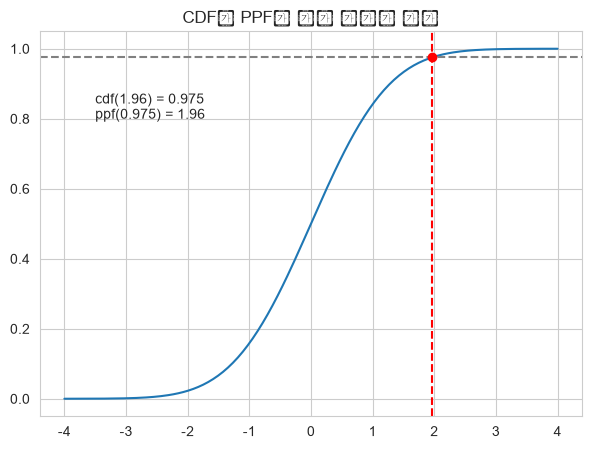

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

x = np.linspace(-4, 4, 200)
cdf_vals = norm.cdf(x)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(x, cdf_vals)
ax.axhline(0.975, color='gray', linestyle='--')
ax.axvline(norm.ppf(0.975), color='red', linestyle='--')
ax.scatter([norm.ppf(0.975)], [0.975], color='red', zorder=5)
ax.annotate(f"cdf(1.96) = 0.975\nppf(0.975) = 1.96",
            xy=(norm.ppf(0.975), 0.975), xytext=(-3.5, 0.8))
ax.set_title("CDF와 PPF는 서로 역함수 관계")
plt.savefig("cdf_ppf.png", dpi=100)
plt.show()

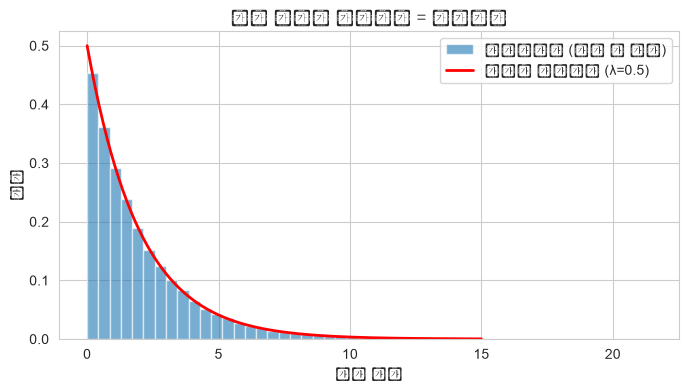

시뮬레이션 평균 대기시간: 2.00
이론적 평균 (1/λ):        2.00


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, poisson

lam = 0.5   # 단위 시간당 평균 0.5건 발생 (예: 평균 대기시간 = 1/0.5 = 2)

# 시뮬레이션: 포아송 과정을 직접 만들어서 "사건 사이 간격"이 지수분포인지 확인
np.random.seed(0)
n_events = 100_000
inter_arrival_times = np.random.exponential(scale=1/lam, size=n_events)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(inter_arrival_times, bins=50, density=True, alpha=0.6, label="시뮬레이션 (사건 간 간격)")

x = np.linspace(0, 15, 200)
ax.plot(x, expon.pdf(x, scale=1/lam), 'r-', lw=2, label=f"이론적 지수분포 (λ={lam})")
ax.set_xlabel("대기 시간")
ax.set_ylabel("밀도")
ax.legend()
ax.set_title("사건 사이의 대기시간 = 지수분포")
plt.savefig("exponential_demo.png", dpi=100)
plt.show()

print(f"시뮬레이션 평균 대기시간: {inter_arrival_times.mean():.2f}")
print(f"이론적 평균 (1/λ):        {1/lam:.2f}")

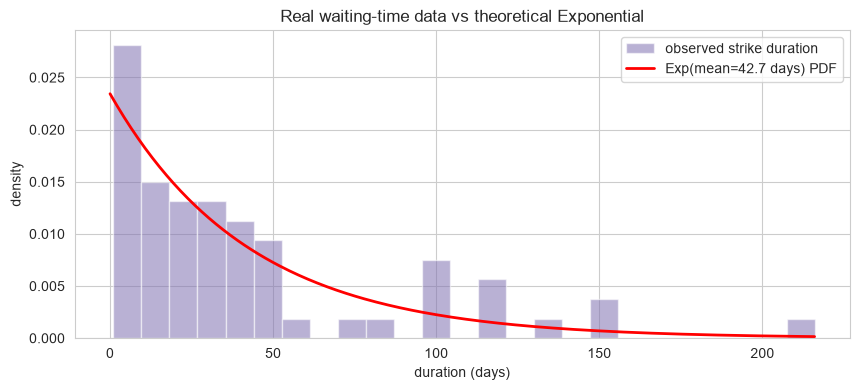

■ 지수분포 판정 신호: 평균 ≈ 표준편차인가?
   표본평균     42.7일
   표본표준편차 45.9일
   표준편차/평균 = 1.07   (1에 가까울수록 지수분포 닮음)

   21일 안에 끝난 파업 비율 : 관측 41.9% / 지수분포 예측 39.3%


In [23]:
# [C14] 예제 3.4: 지수분포 — 실데이터('파업 지속일수')와 이론 PDF 비교
mean_wait = wait.mean()
x = np.linspace(0, wait.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(wait, bins=25, density=True, alpha=0.55, color="#8172B2",
        label="observed strike duration")
ax.plot(x, stats.expon.pdf(x, scale=mean_wait), color="red", lw=2,
        label=f"Exp(mean={mean_wait:.1f} days) PDF")
ax.set_xlabel("duration (days)"); ax.set_ylabel("density")
ax.set_title("Real waiting-time data vs theoretical Exponential")
ax.legend(); plt.show()

print("■ 지수분포 판정 신호: 평균 ≈ 표준편차인가?")
print(f"   표본평균     {wait.mean():.1f}일")
print(f"   표본표준편차 {wait.std():.1f}일")
print(f"   표준편차/평균 = {wait.std() / wait.mean():.2f}   (1에 가까울수록 지수분포 닮음)")

# 지수분포가 맞다면, '평균의 절반보다 짧게 끝날 확률'은 이론적으로 약 39%
half = mean_wait / 2
print(f"\n   {half:.0f}일 안에 끝난 파업 비율 : 관측 {np.mean(wait <= half):.1%}"
      f" / 지수분포 예측 {stats.expon.cdf(half, scale=mean_wait):.1%}")

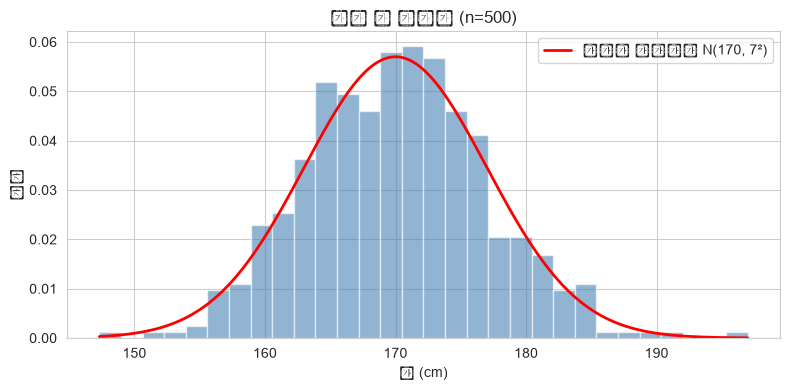

표본 평균: 170.05, 표본 표준편차: 6.86
→ loc=170, scale=7로 설정한 값과 거의 비슷하게 나오는지 확인

시간당 통화 수 (n=500)
표본 평균: 4.992
표본 분산: 5.116
분산/평균 비율: 1.025  (1에 가까우면 포아송 가정과 일치)


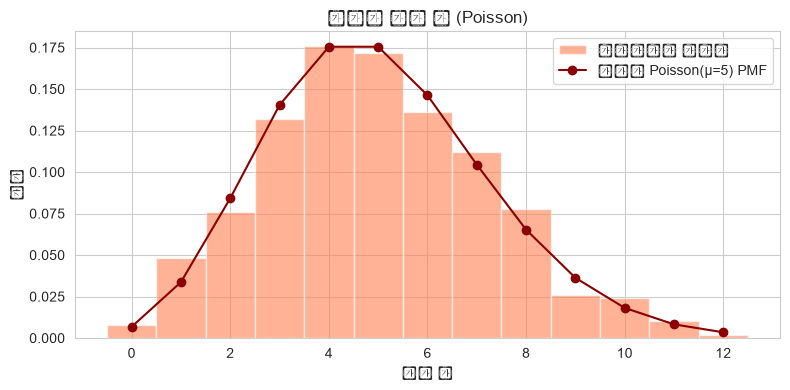

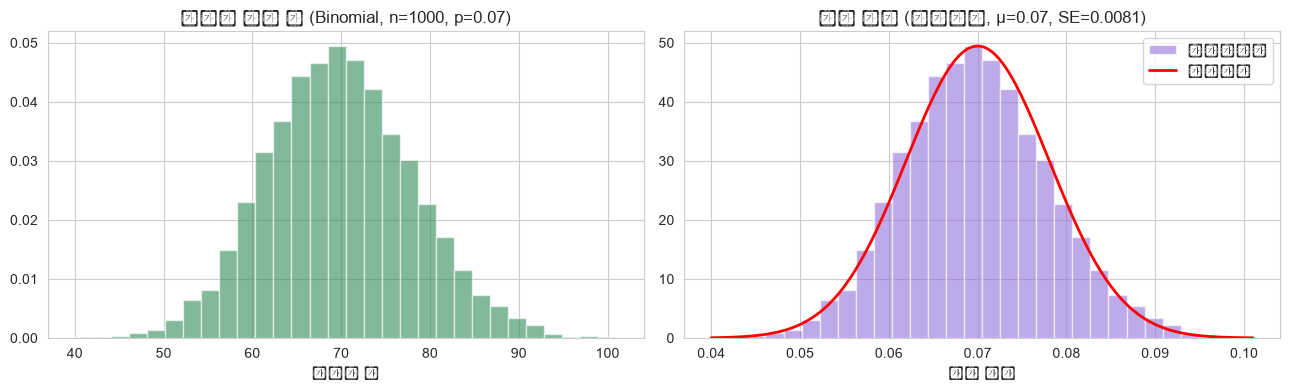


이항분포(사람 수) 평균: 69.86, 표준편차: 8.06
이론값: 평균=70.0, 표준편차=8.07

비율 평균: 0.0699, 표준오차: 0.0081
이론값: 평균=0.07, 표준오차=0.0081


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ─────────────────────────────────────────────
# 1) 가상 키 데이터 (정규분포) — 연속형, 측정값
# ─────────────────────────────────────────────

np.random.seed(42)
heights = stats.norm.rvs(loc=170, scale=7, size=500)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(heights, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='white')

# 이론적 정규분포 곡선 겹쳐 그리기
x = np.linspace(heights.min(), heights.max(), 200)
ax.plot(x, stats.norm.pdf(x, loc=170, scale=7), 'r-', lw=2, label="이론적 정규분포 N(170, 7²)")

ax.set_title("가상 키 데이터 (n=500)")
ax.set_xlabel("키 (cm)")
ax.set_ylabel("밀도")
ax.legend()
plt.tight_layout()
plt.savefig("height_hist.png", dpi=100)
plt.show()

print(f"표본 평균: {heights.mean():.2f}, 표본 표준편차: {heights.std():.2f}")
print("→ loc=170, scale=7로 설정한 값과 거의 비슷하게 나오는지 확인")


# ─────────────────────────────────────────────
# 2) 시간당 통화 수 (포아송분포) — 이산형, 카운트
# ─────────────────────────────────────────────

calls = stats.poisson.rvs(mu=5, size=500)

calls_mean = calls.mean()
calls_var = calls.var()

print(f"\n시간당 통화 수 (n=500)")
print(f"표본 평균: {calls_mean:.3f}")
print(f"표본 분산: {calls_var:.3f}")
print(f"분산/평균 비율: {calls_var / calls_mean:.3f}  (1에 가까우면 포아송 가정과 일치)")

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(calls.min(), calls.max() + 2) - 0.5
ax.hist(calls, bins=bins, density=True, alpha=0.6, color='coral', edgecolor='white', label="시뮬레이션 데이터")

k = np.arange(0, calls.max() + 1)
ax.plot(k, stats.poisson.pmf(k, mu=5), 'o-', color='darkred', label="이론적 Poisson(μ=5) PMF")

ax.set_title("시간당 통화 수 (Poisson)")
ax.set_xlabel("통화 수")
ax.set_ylabel("비율")
ax.legend()
plt.tight_layout()
plt.savefig("calls_hist.png", dpi=100)
plt.show()

n, p = 1000, 0.07

# 이항분포로 직접 시뮬레이션
np.random.seed(0)
coupon_users = stats.binom.rvs(n=n, p=p, size=10000)  # "1000명 중 사용자 수"를 만번 반복 시뮬레이션

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (좌) 이항분포: 사용한 "사람 수"
axes[0].hist(coupon_users, bins=30, density=True, alpha=0.6, color='seagreen')
axes[0].set_title(f"사용한 사람 수 (Binomial, n={n}, p={p})")
axes[0].set_xlabel("사용자 수")

# (우) 비율로 변환: 사용 "비율"
usage_rate = coupon_users / n
axes[1].hist(usage_rate, bins=30, density=True, alpha=0.6, color='mediumpurple', label="시뮬레이션")

# 정규근사 곡선 겹치기
se = np.sqrt(p * (1-p) / n)   # 표준오차
x = np.linspace(usage_rate.min(), usage_rate.max(), 200)
axes[1].plot(x, stats.norm.pdf(x, loc=p, scale=se), 'r-', lw=2, label="정규근사")
axes[1].set_title(f"사용 비율 (정규근사, μ={p}, SE={se:.4f})")
axes[1].set_xlabel("사용 비율")
axes[1].legend()

plt.tight_layout()
plt.savefig("coupon_binomial_vs_normal.png", dpi=100)
plt.show()

print(f"\n이항분포(사람 수) 평균: {coupon_users.mean():.2f}, 표준편차: {coupon_users.std():.2f}")
print(f"이론값: 평균={n*p}, 표준편차={np.sqrt(n*p*(1-p)):.2f}")
print(f"\n비율 평균: {usage_rate.mean():.4f}, 표준오차: {usage_rate.std():.4f}")
print(f"이론값: 평균={p}, 표준오차={se:.4f}")

In [25]:
# ─────────────────────────────────────────────
# 3) "쿠폰 발송 1000명 중 사용한 사람 수" → 어떤 분포?
# ─────────────────────────────────────────────

# 판단 및 근거 (주석 정리):
#
# [사용한 "사람 수"로 볼 때 — 이항분포(Binomial)]
#   - 1000명이라는 "정해진 시행 횟수(n)"가 있고,
#     각 사람은 "사용했다/안 했다"라는 독립적인 베르누이 시행(성공확률 p=0.07)을 겪음.
#   - 이런 "고정된 n번의 독립시행 중 성공 횟수"는 이항분포의 정의와 정확히 일치.
#   → X ~ Binomial(n=1000, p=0.07)
#
#   다만 n이 매우 크고 p가 작지 않다면(np=70, n(1-p)=930 모두 충분히 큼),
#   이항분포는 정규분포로 근사가 잘 되는 영역에 들어감 (np≥5, n(1-p)≥5 조건 만족).
#   → 실무에서는 정규근사로 신뢰구간을 간단히 계산하기도 함.
#
#   * 참고: 만약 "사용한 사람 수"가 아니라 n이 매우 크고 p가 매우 작은 극단적 상황
#     (예: 100만 명 중 사용률 0.01%)이라면 포아송 근사가 더 적합할 수도 있음.
#     하지만 지금처럼 p=7%는 "작다"고 보기 어려워서 포아송보다는
#     이항(혹은 정규근사)이 더 자연스러움.
#
# [같은 데이터를 "비율(7%)" 단위로 볼 때 — 정규분포(Normal)로 근사]
#   - "1000명 중 사용한 사람의 비율(p-hat)"은 이항분포를 n(=1000)으로 나눈 값.
#   - 표본 크기가 충분히 크면(중심극한정리), 이 비율(p-hat)의 분포는
#     평균 p=0.07, 표준오차 sqrt(p(1-p)/n) 인 정규분포에 가까워짐.
#   - 그래서 "전환율이 7%±α%"처럼 신뢰구간을 말할 때는
#     이항분포 자체보다 정규근사를 이용한 비율 신뢰구간 공식을 사용하는 게 실무 표준.
#
# 결론:
#   - "사용한 사람 수"(정수, count) → 이항분포가 원리적으로 정확한 모델
#   - "사용 비율"(연속적인 %) → 정규분포로 근사해서 다루는 게 실무적으로 편리
#   - 즉, 같은 현상이라도 "무엇을 확률변수로 잡느냐"에 따라
#     이산형(이항)으로 볼 수도, 연속형(정규 근사)으로 볼 수도 있음.

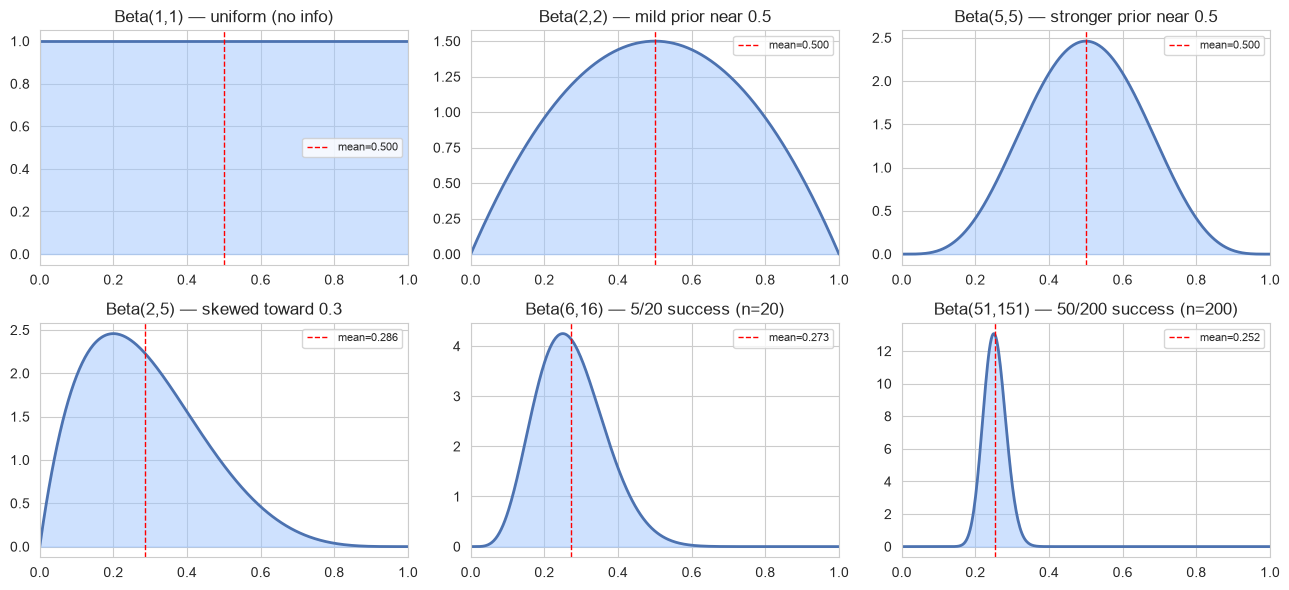

In [26]:
# [C16] 예제 4.1: α, β를 바꾸면 모양이 어떻게 변하나
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
params = [(1, 1), (2, 2), (5, 5),
          (2, 5), (6, 16), (51, 151)]
titles = ["Beta(1,1) — uniform (no info)",
          "Beta(2,2) — mild prior near 0.5",
          "Beta(5,5) — stronger prior near 0.5",
          "Beta(2,5) — skewed toward 0.3",
          "Beta(6,16) — 5/20 success (n=20)",
          "Beta(51,151) — 50/200 success (n=200)"]

x = np.linspace(0, 1, 400)
for ax, (a, b), title in zip(axes.flatten(), params, titles):
    ax.plot(x, stats.beta.pdf(x, a, b), color="#4C72B0", lw=2)
    ax.fill_between(x, stats.beta.pdf(x, a, b), color="#9ec5fe", alpha=0.5)
    mean = a / (a + b)
    ax.axvline(mean, color="red", linestyle="--", lw=1, label=f"mean={mean:.3f}")
    ax.set_title(title); ax.set_xlim(0, 1); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

5/20 (n=20)         95% credible interval = [0.113, 0.472]   width = 0.359
50/200 (n=200)      95% credible interval = [0.195, 0.314]   width = 0.119
500/2000 (n=2000)   95% credible interval = [0.232, 0.269]   width = 0.038


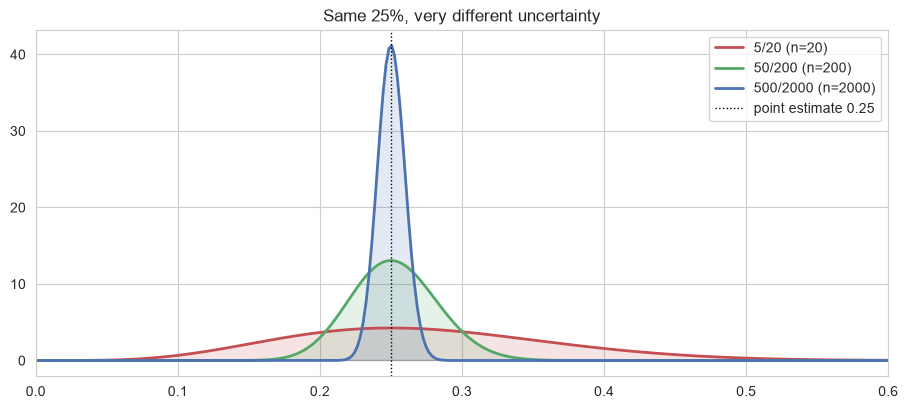

In [27]:
# [C17] 예제 4.2: 5/20 vs 50/200 vs 500/2000 — 같은 25%
data = [(5, 15), (50, 150), (500, 1500)]
labels = ["5/20 (n=20)", "50/200 (n=200)", "500/2000 (n=2000)"]
colors = ["#C44E52", "#55A868", "#4C72B0"]

x = np.linspace(0, 1, 500)
fig, ax = plt.subplots(figsize=(11, 4.5))
for (s, f), lab, c in zip(data, labels, colors):
    a, b = s + 1, f + 1
    pdf = stats.beta.pdf(x, a, b)
    ax.plot(x, pdf, color=c, lw=2, label=lab)
    ax.fill_between(x, pdf, color=c, alpha=0.15)
    # 95% 신용구간(credible interval) 표시
    lo, hi = stats.beta.ppf([0.025, 0.975], a, b)
    print(f"{lab:18s}  95% credible interval = [{lo:.3f}, {hi:.3f}]   width = {hi-lo:.3f}")

ax.axvline(0.25, color="black", linestyle=":", lw=1, label="point estimate 0.25")
ax.set_title("Same 25%, very different uncertainty")
ax.set_xlim(0, 0.6); ax.legend(); plt.show()

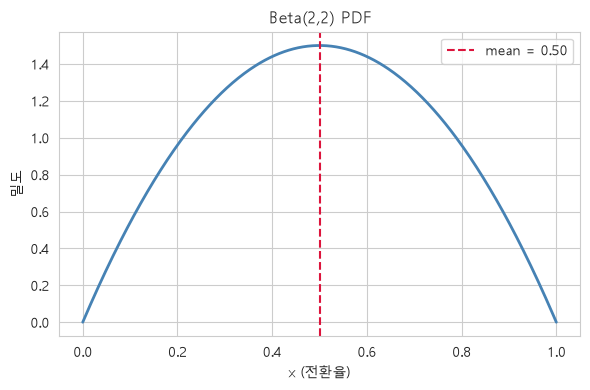

=== 1) Beta(2,2) ===
평균(공식 계산) = 0.5
평균(scipy 검산) = 0.5



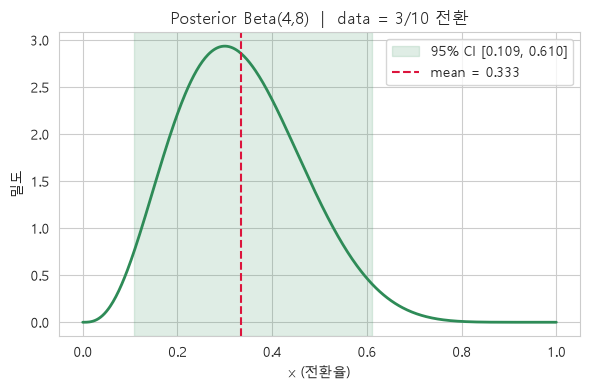

=== 2) 사후분포 Beta(4,8) ===
사후 평균 = 0.3333
95% 신용구간 = [0.1093, 0.6097]



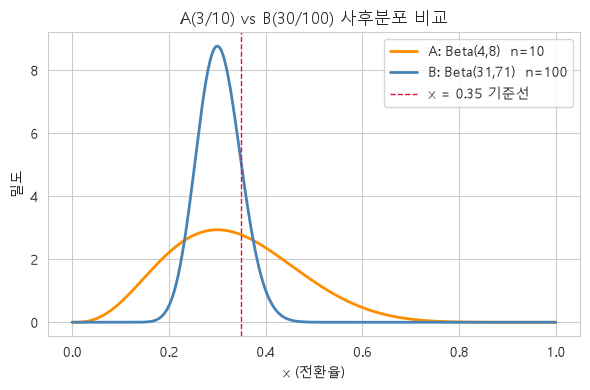

=== 3) A(3/10) vs B(30/100), P(theta >= 0.35) ===
A(n=10)  : P(theta >= 0.35) = 0.4256
B(n=100) : P(theta >= 0.35) = 0.1557



In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

warnings.filterwarnings("ignore")

x = np.linspace(0, 1, 500)

# ------------------------------------------------------------------
# 1) Beta(2, 2)의 PDF와 평균
# ------------------------------------------------------------------
a1, b1 = 2, 2
pdf1 = stats.beta.pdf(x, a1, b1)
mean1 = a1 / (a1 + b1)          # 공식: alpha / (alpha + beta)
mean1_check = stats.beta.mean(a1, b1)  # scipy 내장 함수로 검산

plt.figure(figsize=(6, 4))
plt.plot(x, pdf1, color='steelblue', lw=2)
plt.axvline(mean1, color='crimson', ls='--', label=f'mean = {mean1:.2f}')
plt.title(f'Beta({a1},{b1}) PDF')
plt.xlabel('x (전환율)')
plt.ylabel('밀도')
plt.legend()
plt.tight_layout()
plt.savefig('q1_beta22.png', dpi=110)
plt.show()

print("=== 1) Beta(2,2) ===")
print(f"평균(공식 계산) = {mean1}")
print(f"평균(scipy 검산) = {mean1_check}")
print()

# ------------------------------------------------------------------
# 2) 사전 Beta(1,1) + 데이터(전환 3, 미전환 7) -> 사후 Beta(4,8)
# ------------------------------------------------------------------
prior_a, prior_b = 1, 1
successes, failures = 3, 7
post_a = prior_a + successes   # 1 + 3 = 4
post_b = prior_b + failures    # 1 + 7 = 8

pdf2 = stats.beta.pdf(x, post_a, post_b)
ci_low, ci_high = stats.beta.interval(0.95, post_a, post_b)  # 95% 신용구간
post_mean = post_a / (post_a + post_b)

plt.figure(figsize=(6, 4))
plt.plot(x, pdf2, color='seagreen', lw=2)
plt.axvspan(ci_low, ci_high, color='seagreen', alpha=0.15,
            label=f'95% CI [{ci_low:.3f}, {ci_high:.3f}]')
plt.axvline(post_mean, color='crimson', ls='--', label=f'mean = {post_mean:.3f}')
plt.title(f'Posterior Beta({post_a},{post_b})  |  data = 3/10 전환')
plt.xlabel('x (전환율)')
plt.ylabel('밀도')
plt.legend()
plt.tight_layout()
plt.savefig('q2_beta48.png', dpi=110)
plt.show()

print("=== 2) 사후분포 Beta(4,8) ===")
print(f"사후 평균 = {post_mean:.4f}")
print(f"95% 신용구간 = [{ci_low:.4f}, {ci_high:.4f}]")
print()

# ------------------------------------------------------------------
# 3) A(3/10) vs B(30/100) -> P(진짜 전환율 >= 0.35) 비교
# ------------------------------------------------------------------
# 두 캠페인 모두 사전 Beta(1,1) 가정
a_A, b_A = 1 + 3, 1 + 7      # A: 표본 10, 전환 3
a_B, b_B = 1 + 30, 1 + 70    # B: 표본 100, 전환 30

# P(theta >= 0.35) = 1 - CDF(0.35)
p_A_ge_035 = 1 - stats.beta.cdf(0.35, a_A, b_A)
p_B_ge_035 = 1 - stats.beta.cdf(0.35, a_B, b_B)

pdf_A = stats.beta.pdf(x, a_A, b_A)
pdf_B = stats.beta.pdf(x, a_B, b_B)

plt.figure(figsize=(6, 4))
plt.plot(x, pdf_A, color='darkorange', lw=2, label=f'A: Beta({a_A},{b_A})  n=10')
plt.plot(x, pdf_B, color='steelblue', lw=2, label=f'B: Beta({a_B},{b_B})  n=100')
plt.axvline(0.35, color='crimson', ls='--', lw=1, label='x = 0.35 기준선')
plt.title('A(3/10) vs B(30/100) 사후분포 비교')
plt.xlabel('x (전환율)')
plt.ylabel('밀도')
plt.legend()
plt.tight_layout()
plt.savefig('q3_A_vs_B.png', dpi=110)
plt.show()

print("=== 3) A(3/10) vs B(30/100), P(theta >= 0.35) ===")
print(f"A(n=10)  : P(theta >= 0.35) = {p_A_ge_035:.4f}")
print(f"B(n=100) : P(theta >= 0.35) = {p_B_ge_035:.4f}")
print()

# 이유 정리 (주석)
# ------------------------------------------------------------------
# 점추정(표본 평균)은 A, B 둘 다 0.30으로 동일하다.
# 하지만 표본 크기가 다르기 때문에 "불확실성"의 크기가 다르다.
#   - A: n=10  -> Beta(4,8)   -> 분산이 크고 분포가 넓게 퍼짐
#   - B: n=100 -> Beta(31,71) -> 분산이 작고 분포가 뾰족하게 모임
# 표본이 적은 A는 분포가 넓어서 "혹시 진짜 전환율이 0.35보다 높을 수도
# 있다"는 꼬리 확률(오른쪽 tail)이 B보다 두껍게 남아있다.
# 반대로 B는 데이터가 많아 0.30 근처로 확신이 강해졌기 때문에,
# 0.35 이상일 확률은 A보다 훨씬 작게 계산된다.
# 즉, 평균은 같아도 "0.35를 넘을 가능성"은 표본이 적은 쪽(A)이 더 높다.
# ------------------------------------------------------------------

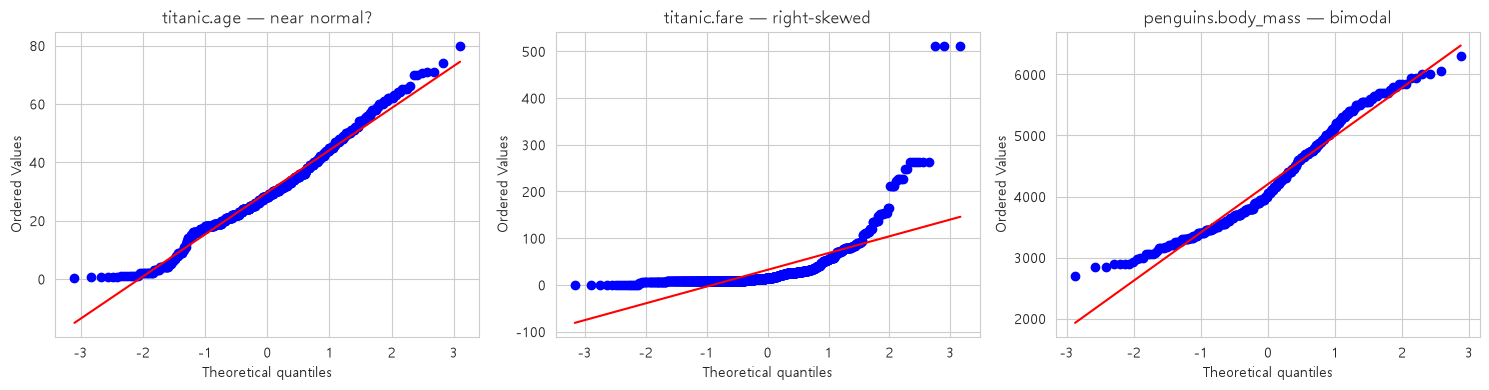

In [30]:
# [C19] 예제 5.1: Q-Q plot — 대칭(나이) vs 우편향(운임) vs 다봉(체중)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

stats.probplot(titanic["age"].dropna(), dist="norm", plot=axes[0])
axes[0].set_title("titanic.age — near normal?")

stats.probplot(titanic["fare"].dropna(), dist="norm", plot=axes[1])
axes[1].set_title("titanic.fare — right-skewed")

stats.probplot(penguins["body_mass_g"].dropna(), dist="norm", plot=axes[2])
axes[2].set_title("penguins.body_mass — bimodal")

plt.tight_layout(); plt.show()

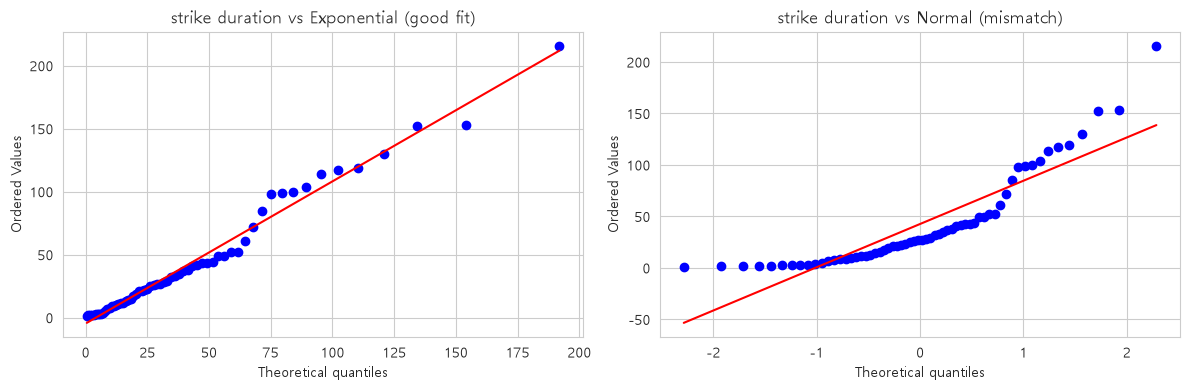

In [31]:
# [C20] 예제 5.2: 다른 이론 분포에도 비교 가능 — 지수분포 적합성
# 실데이터(파업 지속일수 wait)를 두 이론 분포에 각각 견줘봅니다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(wait, dist="expon", sparams=(0, wait.mean()), plot=axes[0])
axes[0].set_title("strike duration vs Exponential (good fit)")
stats.probplot(wait, dist="norm", plot=axes[1])
axes[1].set_title("strike duration vs Normal (mismatch)")
plt.tight_layout(); plt.show()

In [32]:
# [C21] 예제 5.3: Shapiro-Wilk 정규성 검정 — 실제 변수들
named = [
    ("titanic.age",        titanic["age"]),
    ("titanic.fare",       titanic["fare"]),
    ("tips.total_bill",    tips["total_bill"]),
    ("strikes.duration",   wait),
    ("penguins.body_mass", penguins["body_mass_g"]),
]
print(f"{'변수':22s} {'n':>5s} {'W':>8s} {'p-value':>12s}  결론")
print("-" * 62)
for name, s in named:
    s = s.dropna()
    if len(s) > 5000:
        s = s.sample(5000, random_state=42)
    W, p = stats.shapiro(s)
    print(f"{name:22s} {len(s):5d} {W:8.3f} {p:12.2e}  {'정규 기각' if p<0.05 else '정규 채택'}")

# ★ 다봉의 비밀: 펭귄 체중을 '종(species)별'로 나누면?
print("\n[펭귄 체중을 종별로 나누면]")
for sp, g in penguins.groupby("species"):
    s = g["body_mass_g"].dropna()
    W, p = stats.shapiro(s)
    print(f"  {sp:10s} n={len(s):3d}  p={p:.3f}  → {'정규 기각' if p<0.05 else '정규 채택(종 내부는 단봉!)'}")

변수                         n        W      p-value  결론
--------------------------------------------------------------
titanic.age              714    0.981     7.34e-08  정규 기각
titanic.fare             891    0.522     1.08e-43  정규 기각
tips.total_bill          244    0.920     3.32e-10  정규 기각
strikes.duration          62    0.805     1.27e-07  정규 기각
penguins.body_mass       342    0.959     3.68e-08  정규 기각

[펭귄 체중을 종별로 나누면]
  Adelie     n=151  p=0.032  → 정규 기각
  Chinstrap  n= 68  p=0.561  → 정규 채택(종 내부는 단봉!)
  Gentoo     n=123  p=0.234  → 정규 채택(종 내부는 단봉!)


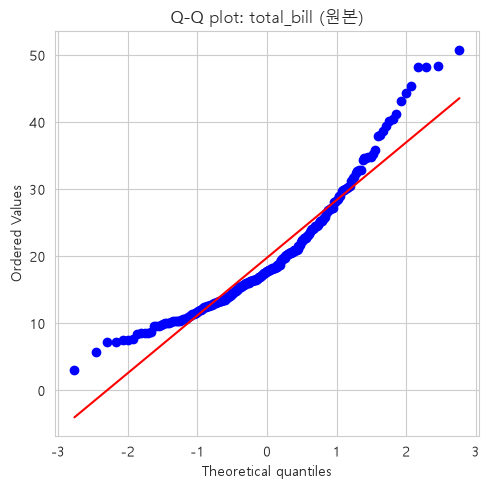

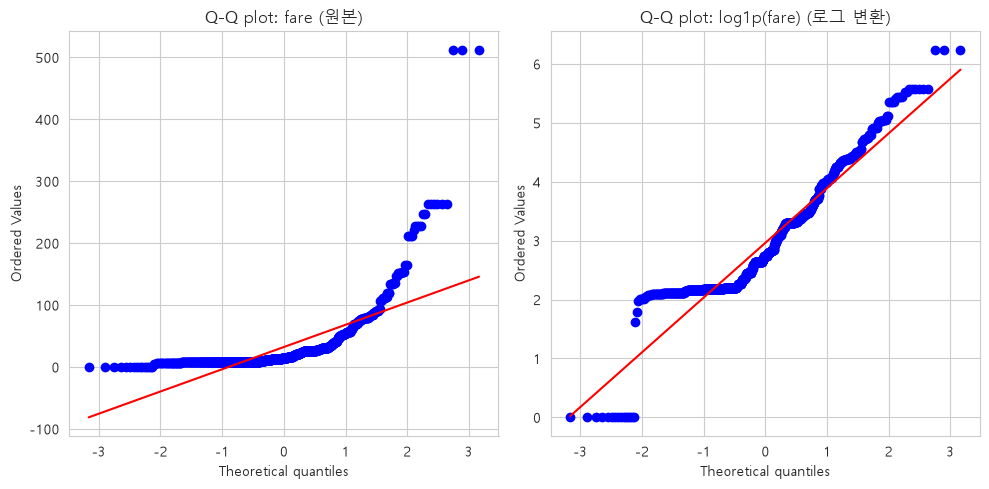

In [33]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

tips = sns.load_dataset('tips')
titanic = sns.load_dataset('titanic')

# ------------------------------------------------------------------
# 1) tips["total_bill"]의 Q-Q plot (정규분포 기준)
# ------------------------------------------------------------------
plt.figure(figsize=(5, 5))
stats.probplot(tips['total_bill'], dist='norm', plot=plt)
plt.title('Q-Q plot: total_bill (원본)')
plt.tight_layout()
plt.savefig('q1_totalbill_qq.png', dpi=110)
plt.show()

# 시각적 평가 포인트:
# - 점들이 대각선(빨간 기준선)을 따라가면 정규분포에 가깝다는 뜻
# - total_bill은 오른쪽 꼬리(고액 계산서)가 길기 때문에
#   오른쪽 위 끝부분에서 점들이 기준선 위로 크게 벗어나는 패턴이 나타남
#   -> 오른쪽으로 치우친(right-skewed) 분포 = 정규성 위반

# ------------------------------------------------------------------
# 2) titanic["fare"] 원본 vs 로그 변환(log1p) Q-Q plot 비교
# ------------------------------------------------------------------
fare_raw = titanic['fare']
fare_log = np.log1p(titanic['fare'])   # log(1+x), 0값 처리 안전

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

stats.probplot(fare_raw, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q plot: fare (원본)')

stats.probplot(fare_log, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot: log1p(fare) (로그 변환)')

plt.tight_layout()
plt.savefig('q2_fare_qq_compare.png', dpi=110)
plt.show()

# 시각적 평가 포인트:
# - 원본 fare: 대부분 저가 요금에 몰려있고 소수의 고가 요금이 있어
#   오른쪽 끝에서 점들이 기준선을 크게 벗어남 (심한 오른쪽 꼬리)
# - log1p(fare): 큰 값들을 압축하는 로그 변환 특성상
#   오른쪽 꼬리가 눌리면서 점들이 기준선에 훨씬 가깝게 정렬됨
# - 다만 fare=0인 승객(무료 승선) 때문에 왼쪽 끝에서는 여전히
#   약간의 이탈이 남아있을 수 있음
# 결론: 로그 변환 후 원본보다 정규분포에 더 가까워짐

In [34]:
import numpy as np
import pandas as pd
from scipy import stats

def diagnose_normality(series, group_col=None, df=None, alpha=0.05):
    """
    Shapiro-Wilk p≈0이 나왔을 때, 분석을 멈출지 판단하기 위한
    보조 진단 정보를 함께 정리하는 함수.
    """
    results = {}

# 샤피로 윌크 검정 방법의 가장 큰 함정은
# 표본이 클수록 검정력이 말도 안되게 좋아진다는 점이다.

    # ------------------------------------------------------------------
    # 1) 표본 크기 확인 (가장 먼저 봐야 할 정보)
    #    n이 크면(대략 300~500 이상) Shapiro-Wilk는 사소한 편차에도
    #    p≈0을 뱉는다. 이 경우 p-value 자체보다 "얼마나 비정규인지"의
    #    크기(effect size 개념)를 봐야 한다.
    # ------------------------------------------------------------------
    n = series.dropna().shape[0]
    results['n'] = n

    # ------------------------------------------------------------------
    # 2) 왜도(skewness), 첨도(kurtosis) — 비정규성의 "크기"를 정량화
    #    |skew| < 0.5, |kurtosis| < 1 정도면 실무적으로는 정규분포에
    #    가깝다고 취급하는 경우가 많다 (엄밀한 기준은 아니지만 참고치).
    #    p-value는 유의성만 알려줄 뿐, 얼마나 벗어났는지는 알려주지 않는다.
    # ------------------------------------------------------------------
    results['skewness'] = stats.skew(series.dropna())
    results['kurtosis'] = stats.kurtosis(series.dropna())  # excess kurtosis

    # ------------------------------------------------------------------
    # 3) Q-Q plot 시각 확인 (숫자만으로 판단하지 않기)
    #    - 꼬리 부분만 살짝 벗어나는가? (흔함, 큰 문제 아닐 수 있음)
    #    - 전체적으로 S자 형태로 심하게 휘는가? (실질적 비정규성)
    # ------------------------------------------------------------------
    # stats.probplot(series.dropna(), dist='norm', plot=plt)  # 실제 실행 시 주석 해제

    # ------------------------------------------------------------------
    # 4) 어떤 후속 분석을 할 것인가가 핵심 판단 기준
    #    - t-test, 회귀분석 등은 n이 충분히 크면(대략 30~수백 이상)
    #      중심극한정리(CLT) 덕분에 정규성 위반에 상당히 강건(robust)하다.
    #      -> "정규성 위반 = 무조건 분석 불가"가 아니다.
    #    - 반대로 n이 작고, 분석이 정규성에 민감한 방법(예: 정확검정,
    #      작은 표본의 신뢰구간)이라면 위반이 실제로 문제가 된다.
    # ------------------------------------------------------------------

    # 5) 그룹별 분석이 목적이라면, 그룹별로 쪼개서 재검증
    if group_col is not None and df is not None:
        group_results = {}
        for name, sub in df.groupby(group_col):
            vals = sub[series.name].dropna()
            if len(vals) >= 3:  # Shapiro는 최소 3개 이상 필요
                stat, p = stats.shapiro(vals)
                group_results[name] = {
                    'n': len(vals), 'shapiro_p': p,
                    'skew': stats.skew(vals)
                }
        results['group_level'] = group_results
        # 주의: 그룹별 n이 너무 작으면(예: n<20) 검정력 부족으로
        # p-value를 신뢰하기 어렵다. 이때는 skew/kurtosis, Q-Q plot 등
        # 시각적 판단에 더 무게를 둬야 한다.

    return results


# ------------------------------------------------------------------
# 최종 판단 기준 정리 (주석)
# ------------------------------------------------------------------
# Q: Shapiro-Wilk에서 모든 변수가 p ≈ 0이면 분석을 멈춰야 하는가?
# A: 아니다. 다음을 순서대로 확인한 뒤 판단해야 한다.
#
#   1. 표본 크기(n)가 큰가?
#      -> n이 크면 p≈0은 자연스러운 결과일 수 있다.
#         (Shapiro-Wilk는 n이 커질수록 극도로 민감해짐)
#
#   2. 왜도/첨도로 비정규성의 "크기"를 확인했는가?
#      -> 통계적 유의성(p-value)과 실질적 유의성(effect size)은 다르다.
#
#   3. Q-Q plot으로 어떤 패턴의 이탈인지 눈으로 확인했는가?
#      -> 꼬리만 살짝 벗어나는지, 전체적으로 심하게 휘는지는
#         p-value만으로 알 수 없다.
#
#   4. 목적하는 분석 방법이 정규성에 얼마나 민감한가?
#      -> t-test/회귀는 n이 크면 CLT 덕분에 상당히 강건하다.
#         반면 작은 표본에서의 정확검정 등은 민감하다.
#
#   5. (그룹 비교가 목적이라면) 그룹별로 재검증했는가?
#      -> 전체를 합친 분포는 여러 그룹이 섞여 쌍봉 형태가 되면서
#         가짜로 "비정규"처럼 보일 수 있다. 이 경우 그룹별 검증이
#         더 정확한 진단이다. 단, 그룹별 n이 작아지면 검정력이
#         떨어지므로 skew/kurtosis, Q-Q plot을 함께 봐야 한다.
#
#   결론: "p≈0 → 중단"이 아니라, "p≈0 + n 확인 + 효과크기 확인 +
#   시각적 확인 + 목적에 맞는 민감도 판단"까지 거친 뒤
#   비모수 검정(Mann-Whitney U, Kruskal-Wallis 등)으로 전환할지,
#   아니면 그대로 진행해도 될지를 결정해야 한다.
# ------------------------------------------------------------------

## Mini Project

[기술통계]
평균: 32.20  중앙값: 14.45  표준편차: 49.69
왜도: 4.78  첨도: 33.20


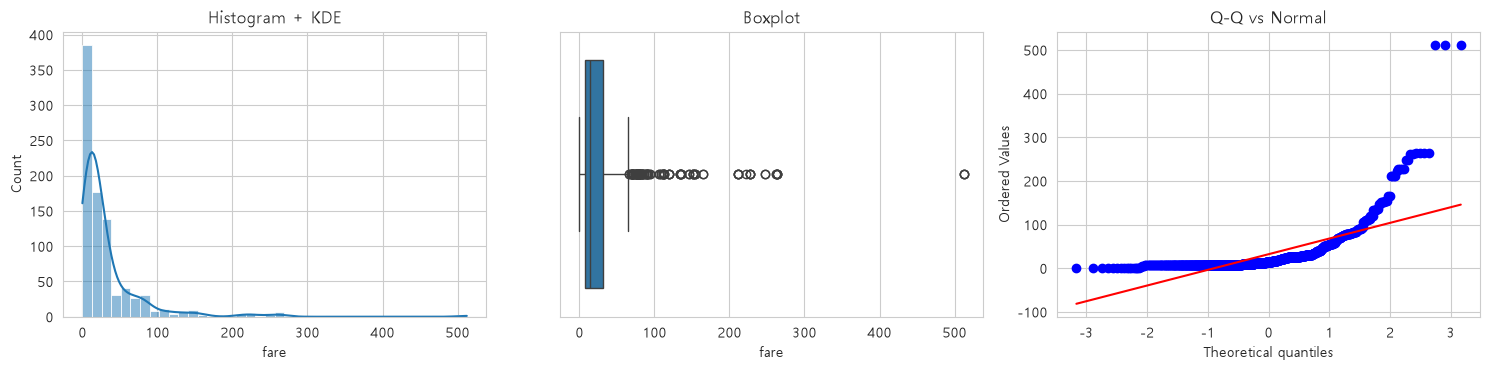


[Shapiro-Wilk] W=0.5219, p=1.08e-43 → 정규 기각
[log1p 변환 후 Shapiro] W=0.9152, p=6.64e-22 → 정규 기각


In [35]:
# [C23] 시나리오 1 — titanic.fare 진단
s = titanic["fare"].dropna()

# (a) 기술통계
print("[기술통계]")
print(f"평균: {s.mean():,.2f}  중앙값: {s.median():,.2f}  표준편차: {s.std():,.2f}")
print(f"왜도: {stats.skew(s):.2f}  첨도: {stats.kurtosis(s):.2f}")

# (b) 시각적 진단
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
sns.histplot(s, bins=40, kde=True, ax=axes[0]); axes[0].set_title("Histogram + KDE")
sns.boxplot(x=s, ax=axes[1]); axes[1].set_title("Boxplot")
stats.probplot(s, dist="norm", plot=axes[2]); axes[2].set_title("Q-Q vs Normal")
plt.tight_layout(); plt.show()

# (c) 정규성 검정
W, p = stats.shapiro(s)
print(f"\n[Shapiro-Wilk] W={W:.4f}, p={p:.3g} → {'정규 채택' if p>0.05 else '정규 기각'}")

# (d) 로그 변환 비교
log_s = np.log1p(s)
W2, p2 = stats.shapiro(log_s)
print(f"[log1p 변환 후 Shapiro] W={W2:.4f}, p={p2:.3g} → {'정규 채택' if p2>0.05 else '정규 기각'}")

n = 996   평균 1.93   분산 11.25   (포아송이라면 둘이 비슷해야 함)
중앙값 1   최댓값 50   0회 비율 41.2%
왜도 6.66   첨도 79.47


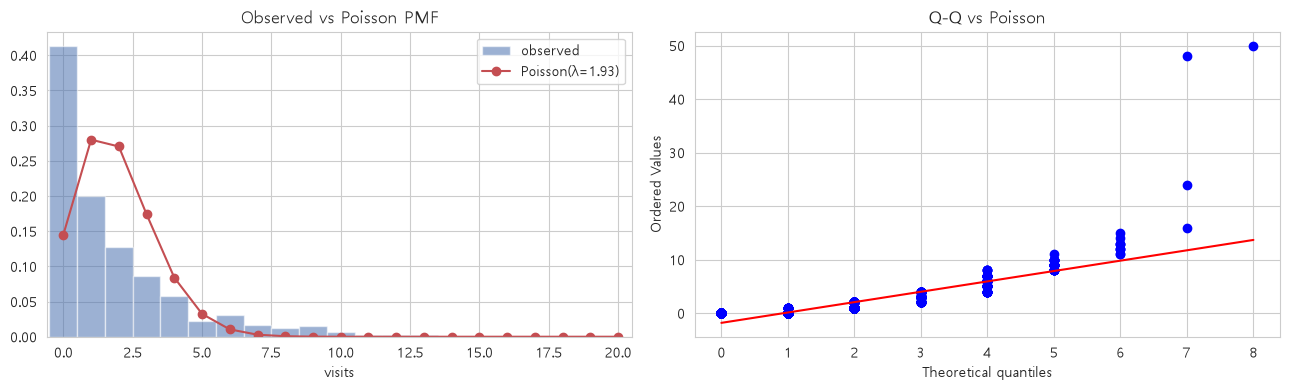


분산/평균 비 = 5.83
→ 1 근처면 포아송, 훨씬 크면 과대산포(음이항 후보)입니다: 과대산포 → 음이항·영과잉 모형 검토


In [36]:
# [C24] 시나리오 2 — visits(카운트 변수) 진단
s = visits
print(f"n = {len(s)}   평균 {s.mean():.2f}   분산 {s.var():.2f}   (포아송이라면 둘이 비슷해야 함)")
print(f"중앙값 {s.median():.0f}   최댓값 {s.max():.0f}   0회 비율 {np.mean(s == 0):.1%}")
print(f"왜도 {stats.skew(s):.2f}   첨도 {stats.kurtosis(s):.2f}")

lam = s.mean()
x_int = np.arange(0, 21)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(s, bins=np.arange(0, 22) - 0.5, density=True, alpha=0.55,
             color="#4C72B0", label="observed")
axes[0].plot(x_int, stats.poisson.pmf(x_int, lam), "o-", color="#C44E52",
             label=f"Poisson(λ={lam:.2f})")
axes[0].set_xlim(-0.6, 20.5); axes[0].set_xlabel("visits")
axes[0].set_title("Observed vs Poisson PMF"); axes[0].legend()

stats.probplot(s, dist="poisson", sparams=(lam,), plot=axes[1])
axes[1].set_title("Q-Q vs Poisson")
plt.tight_layout(); plt.show()

ratio = s.var() / s.mean()
print(f"\n분산/평균 비 = {ratio:.2f}")
print("→ 1 근처면 포아송, 훨씬 크면 과대산포(음이항 후보)입니다:",
      "포아송 적합" if ratio < 1.5 else "과대산포 → 음이항·영과잉 모형 검토")

small (n=40)   연락   1/   40 = 0.025   95% 신용구간 [0.006, 0.129]  폭=0.123
full data      연락 392/ 4870 = 0.080   95% 신용구간 [0.073, 0.088]  폭=0.015


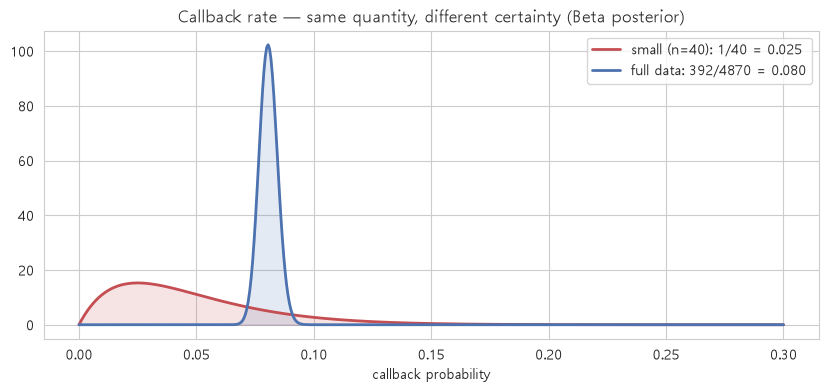

In [37]:
# [C25] 시나리오 3 — 면접 연락률(call)을 베타분포로
# 같은 연락률, 다른 표본 크기 → 다른 확신(불확실성)
small = call.sample(40, random_state=42)     # 적은 표본
big   = call                                  # 전체 표본

x = np.linspace(0, 0.3, 500)
fig, ax = plt.subplots(figsize=(10, 4))
for name, sub, c in [("small (n=40)", small, "#C44E52"), ("full data", big, "#4C72B0")]:
    s_cnt, n = int(sub.sum()), len(sub)
    a, b = s_cnt + 1, (n - s_cnt) + 1          # 사전 Beta(1,1) → 사후 Beta(1+성공, 1+실패)
    lo, hi = stats.beta.ppf([0.025, 0.975], a, b)
    ax.plot(x, stats.beta.pdf(x, a, b), color=c, lw=2,
            label=f"{name}: {s_cnt}/{n} = {s_cnt/n:.3f}")
    ax.fill_between(x, stats.beta.pdf(x, a, b), color=c, alpha=0.15)
    print(f"{name:14s} 연락 {s_cnt:3d}/{n:5d} = {s_cnt/n:.3f}   "
          f"95% 신용구간 [{lo:.3f}, {hi:.3f}]  폭={hi-lo:.3f}")
ax.set_title("Callback rate — same quantity, different certainty (Beta posterior)")
ax.set_xlabel("callback probability"); ax.legend()
plt.show()

[전체] 평균: 4202  중앙값: 4050  왜도: 0.47  첨도: -0.73
[전체 Shapiro] p=3.68e-08 → 정규 기각


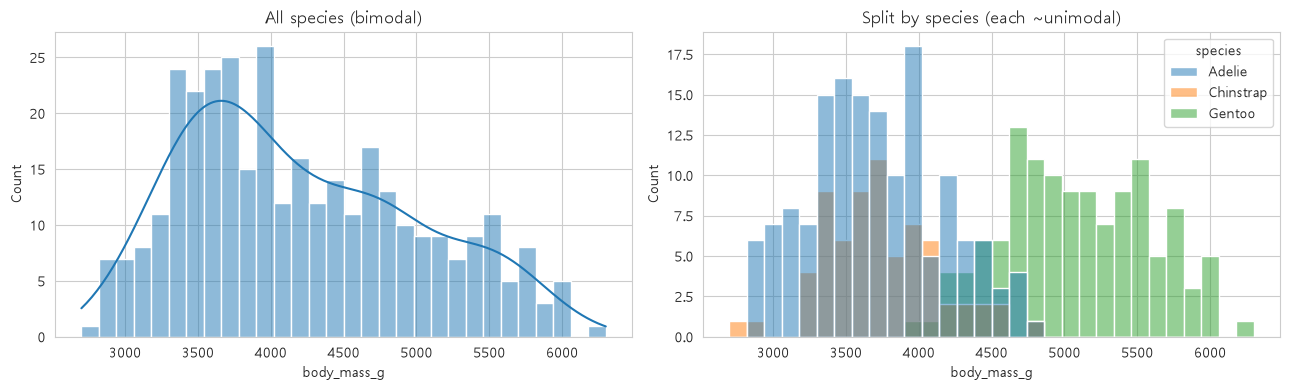


[종별 정규성]
  Adelie     평균=3701  p=0.032 → 정규 기각
  Chinstrap  평균=3733  p=0.561 → 정규 채택
  Gentoo     평균=5076  p=0.234 → 정규 채택


In [38]:
# [C26] 시나리오 4 — penguins.body_mass 진단 → 종(species) 분리
bm = penguins.dropna(subset=["body_mass_g"])
s = bm["body_mass_g"]
print(f"[전체] 평균: {s.mean():.0f}  중앙값: {s.median():.0f}  왜도: {stats.skew(s):.2f}  첨도: {stats.kurtosis(s):.2f}")
W, p = stats.shapiro(s)
print(f"[전체 Shapiro] p={p:.2e} → {'정규 기각' if p<0.05 else '정규 채택'}")

# 전체(다봉) vs 종별(각각 단봉) 비교 — seaborn hue로 집단을 색으로 분리
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(s, bins=30, kde=True, ax=axes[0]); axes[0].set_title("All species (bimodal)")
sns.histplot(data=bm, x="body_mass_g", hue="species", bins=30, ax=axes[1])
axes[1].set_title("Split by species (each ~unimodal)")
plt.tight_layout(); plt.show()

print("\n[종별 정규성]")
for sp, g in bm.groupby("species"):
    W, p = stats.shapiro(g["body_mass_g"])
    print(f"  {sp:10s} 평균={g['body_mass_g'].mean():.0f}  p={p:.3f} → {'정규 기각' if p<0.05 else '정규 채택'}")

In [39]:
# [C27] 진단 리포트의 표를 자동 생성하는 함수
def diagnose(series, name):
    s = series.dropna()
    sample = s.sample(min(len(s), 5000), random_state=42)
    W, p = stats.shapiro(sample)
    return {
        "변수": name,
        "n": len(s),
        "평균": round(s.mean(), 3),
        "중앙값": round(s.median(), 3),
        "표준편차": round(s.std(), 3),
        "왜도": round(stats.skew(s), 2),
        "첨도": round(stats.kurtosis(s), 2),
        "분산/평균": round(s.var() / s.mean(), 2) if s.min() >= 0 else None,
        "Shapiro p": round(p, 4),
        "정규성": "기각" if p < 0.05 else "채택",
    }

report = pd.DataFrame([
    diagnose(titanic["fare"],         "titanic.fare"),
    diagnose(titanic["age"],          "titanic.age"),
    diagnose(visits,                  "visits (count)"),
    diagnose(wait,                    "strikes.duration"),
    diagnose(penguins["body_mass_g"], "penguins.body_mass"),
    diagnose(tips["total_bill"],      "tips.total_bill"),
])
report

,변수,n,평균,중앙값,표준편차,왜도,첨도,분산/평균,Shapiro p,정규성
0,titanic.fare,891,32.204,14.454,49.693,4.78,33.20,76.68,0.0,기각
1,titanic.age,714,29.699,28.000,14.526,0.39,0.17,7.11,0.0,기각
2,visits (count),996,1.931,1.000,3.354,6.66,79.47,5.83,0.0,기각
3,strikes.duration,62,42.661,27.000,45.855,1.62,2.40,49.29,0.0,기각
4,penguins.body_mass,342,4201.754,4050.000,801.955,0.47,-0.73,153.06,0.0,기각
5,tips.total_bill,244,19.786,17.795,8.902,1.13,1.17,4.01,0.0,기각
